# Tip 3 — Distribution-Shape Features of the 20-Day Window

Beyond the level of returns, the *shape* of the 20-day path carries signal:

1. **Downside vol** — std of negative return days only (asymmetric risk)
2. **Skew** — tail direction of the return distribution
3. **Fraction / count of positive days** — hit rate over the window
4. **Longest up/down streak** — persistence of direction
5. **Max drawdown + distance from peak** — path-dependent risk
6. **Vol interactions** — vol-adjusted momentum; vol regime modulates how momentum signals behave

In [7]:
import sys
sys.path.insert(0, '..')   # so tip3_features.py (in code/) is importable

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set()

import lightgbm as lgbm
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold

import tip3_features

### Load data

In [8]:
X_train = pd.read_csv('../../data/X_train.csv', index_col='ROW_ID')
X_test  = pd.read_csv('../../data/X_test.csv',  index_col='ROW_ID')
y_train = pd.read_csv('../../data/y_train.csv', index_col='ROW_ID')
sample_submission = pd.read_csv('../../submission/sample_submission.csv', index_col='ROW_ID')

RET_cols = [f'RET_{i}'           for i in range(1, 21)]
VOL_cols = [f'SIGNED_VOLUME_{i}' for i in range(1, 21)]

### Feature engineering

#### A. Benchmark features (required — Tip 3 vol interactions depend on `STD_PERF_20` and `AVERAGE_PERF_*`)

In [9]:
def add_benchmark_features(df):
    for i in [3, 5, 10, 15, 20]:
        df[f'AVERAGE_PERF_{i}'] = df[RET_cols[:i]].mean(axis=1)
        df[f'ALLOCATIONS_AVERAGE_PERF_{i}'] = df.groupby('TS')[f'AVERAGE_PERF_{i}'].transform('mean')
    df['STD_PERF_20'] = df[RET_cols].std(axis=1)
    df['ALLOCATIONS_STD_PERF_20'] = df.groupby('TS')['STD_PERF_20'].transform('mean')
    return df

X_train = add_benchmark_features(X_train)
X_test  = add_benchmark_features(X_test)

benchmark_features = (
    RET_cols + VOL_cols + ['MEDIAN_DAILY_TURNOVER']
    + [f'AVERAGE_PERF_{i}'             for i in [3, 5, 10, 15, 20]]
    + [f'ALLOCATIONS_AVERAGE_PERF_{i}' for i in [3, 5, 10, 15, 20]]
    + ['STD_PERF_20', 'ALLOCATIONS_STD_PERF_20']
)

#### B. Tip 3 — Distribution shape, streaks, drawdown, vol interactions

In [10]:
X_train, tip3_feats = tip3_features.add_features(X_train, RET_cols, VOL_cols)
X_test,  _          = tip3_features.add_features(X_test,  RET_cols, VOL_cols)

print(f"Tip 3 features ({len(tip3_feats)}):", tip3_feats)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Tip 3 features (13): ['DOWNSIDE_VOL', 'RET_SKEW', 'FRAC_POS_20', 'COUNT_POS_5', 'LONGEST_UP_STREAK', 'LONGEST_DOWN_STREAK', 'POS_LAST_3', 'MAX_DRAWDOWN', 'DIST_FROM_PEAK', 'AVERAGE_PERF_3_DIV_VOL', 'AVERAGE_PERF_5_DIV_VOL', 'AVERAGE_PERF_10_DIV_VOL', 'AVERAGE_PERF_20_DIV_VOL']


#### Quick sanity check — distribution of new features

In [11]:
X_train[tip3_feats].describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
DOWNSIDE_VOL,0.001555,0.000959,0.000000,0.014986
RET_SKEW,-0.023733,0.611793,-4.214517,4.427881
FRAC_POS_20,0.506176,0.115705,0.000000,1.000000
COUNT_POS_5,2.538624,1.130367,0.000000,5.000000
LONGEST_UP_STREAK,3.816644,1.643143,0.000000,20.000000
LONGEST_DOWN_STREAK,3.711556,1.589365,0.000000,20.000000
POS_LAST_3,1.525811,0.878447,0.000000,3.000000
MAX_DRAWDOWN,0.011866,0.008935,0.000000,0.191692
DIST_FROM_PEAK,0.007923,0.008796,0.000000,0.149023
AVERAGE_PERF_3_DIV_VOL,0.017640,0.600727,-3.203693,2.721250


### Build final feature list

In [12]:
features = benchmark_features + tip3_feats
print(f"Total features: {len(features)}  "
      f"(benchmark={len(benchmark_features)}, tip3={len(tip3_feats)})")

Total features: 66  (benchmark=53, tip3=13)


### LightGBM — 8-fold cross-validation on dates

In [13]:
lgbm_params = {
    "objective":     "mse",
    "metric":        "mse",
    "num_threads":   50,
    "seed":          42,
    "verbosity":     -1,
    "learning_rate": 1e-2,
    "max_depth":     3,
}
NUM_BOOST_ROUND = 500

train_dates = X_train['TS'].unique()
scores, models = [], []

splits = KFold(n_splits=8, shuffle=True, random_state=0).split(train_dates)

for fold, (tr_idx, val_idx) in enumerate(splits):
    tr_mask  = X_train['TS'].isin(train_dates[tr_idx])
    val_mask = X_train['TS'].isin(train_dates[val_idx])

    X_tr  = X_train.loc[tr_mask,  features].fillna(0)
    y_tr  = y_train.loc[tr_mask,  'target']
    X_val = X_train.loc[val_mask, features].fillna(0)
    y_val = y_train.loc[val_mask, 'target']

    model = lgbm.train(lgbm_params,
                       lgbm.Dataset(X_tr, label=y_tr.values),
                       num_boost_round=NUM_BOOST_ROUND)

    preds = model.predict(X_val.values, num_threads=lgbm_params['num_threads'])
    acc   = accuracy_score((y_val > 0).astype(int), (preds > 0).astype(int))

    models.append(model)
    scores.append(acc)
    print(f"Fold {fold+1} — Accuracy: {acc*100:.2f}%")

mean = np.mean(scores) * 100
std  = np.std(scores)  * 100
print(f"\nAccuracy: {mean:.2f}% ± {std:.2f}%  [{mean-std:.2f} ; {mean+std:.2f}]")

Fold 1 — Accuracy: 52.08%
Fold 2 — Accuracy: 52.27%
Fold 3 — Accuracy: 51.90%
Fold 4 — Accuracy: 52.17%
Fold 5 — Accuracy: 51.99%
Fold 6 — Accuracy: 52.36%
Fold 7 — Accuracy: 52.50%
Fold 8 — Accuracy: 52.06%

Accuracy: 52.17% ± 0.19%  [51.98 ; 52.35]


### Feature importance (top 30 by gain)

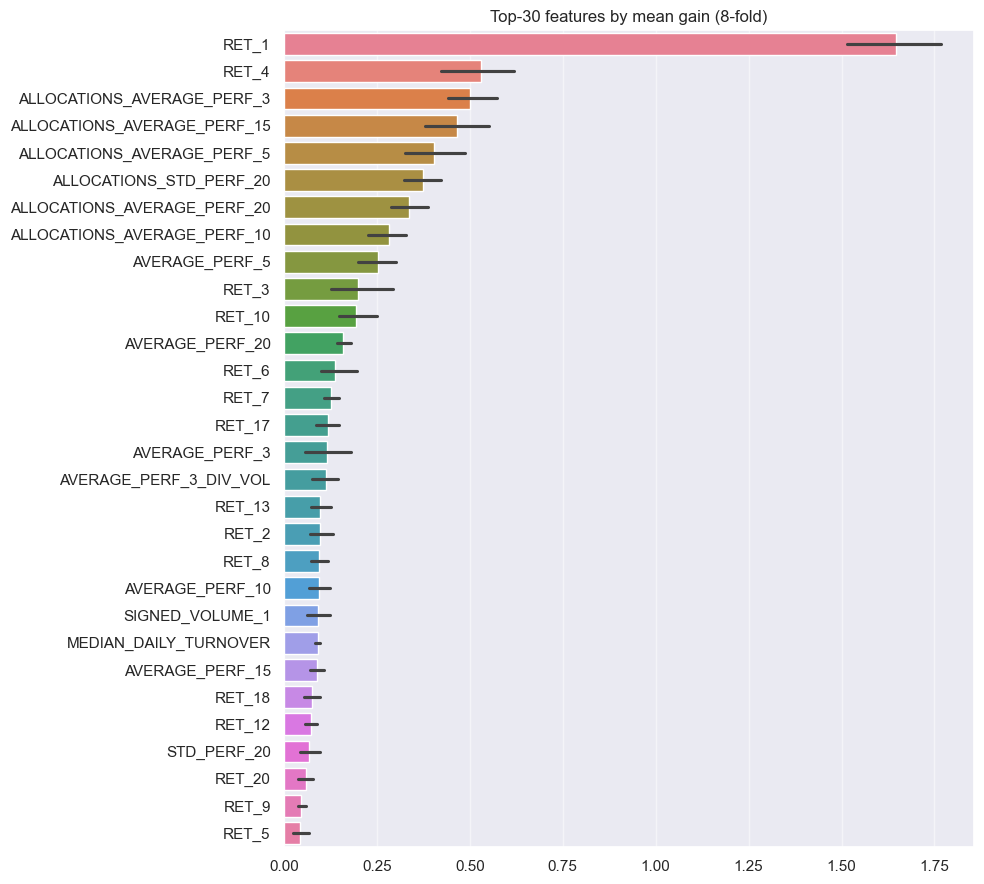

In [14]:
importances = pd.DataFrame(
    [m.feature_importance(importance_type='gain') for m in models],
    columns=features
)
top30 = importances.mean().sort_values(ascending=False).head(30).index

plt.figure(figsize=(10, 9))
sns.barplot(data=importances[top30], orient='h',
            order=importances[top30].mean().sort_values(ascending=False).index)
plt.title("Top-30 features by mean gain (8-fold)")
plt.tight_layout()
plt.show()

### Final model + submission

In [15]:
final_model = lgbm.train(
    lgbm_params,
    lgbm.Dataset(X_train[features].fillna(0), label=y_train['target'].values),
    num_boost_round=NUM_BOOST_ROUND
)

test_preds = final_model.predict(X_test[features].fillna(0).values)
submission = pd.DataFrame(
    (test_preds > 0).astype(int),
    index=sample_submission.index,
    columns=['TARGET']
)
submission.to_csv('preds_tip3_distribution_shape.csv')
print("Saved preds_tip3_distribution_shape.csv")
submission['TARGET'].value_counts()

Saved preds_tip3_distribution_shape.csv


TARGET
1    19109
0    12761
Name: count, dtype: int64